In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2

In [3]:
df = pd.read_csv('faces.csv')

In [4]:
df

,image_name,width,height,x0,y0,x1,y1
0,00001722.jpg,1333,2000,490,320,687,664
1,00001044.jpg,2000,1333,791,119,1200,436
2,00001050.jpg,667,1000,304,155,407,331
3,00001736.jpg,626,417,147,14,519,303
4,00003121.jpg,626,418,462,60,599,166
...,...,...,...,...,...,...,...
3345,00002232.jpg,620,349,4,36,186,158
3346,00002232.jpg,620,349,122,103,344,248
3347,00002232.jpg,620,349,258,118,541,303
3348,00002232.jpg,620,349,215,11,362,108


In [13]:
X = []
y = []
for i in range(0, len(df)):
    image_name = df.iloc[i]['image_name']
    h = df.iloc[i]['height']
    w = df.iloc[i]['width']
    x0 = df.iloc[i]['x0']
    x1 = df.iloc[i]['x1']
    y0 = df.iloc[i]['y0']
    y1 = df.iloc[i]['y1']
    image = mpimg.imread(f'images/{image_name}')
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = cv2.resize(image, (150, 150))
    image = image / 255
    image = image.reshape(150, 150, 1)
    x0 = x0 * image.shape[1] / w
    x1 = x1 * image.shape[1] / w
    y0 = y0 * image.shape[0] / h
    y1 = y1 * image.shape[0] / h
    X.append(image)
    y.append([x0, y0, x1, y1])
X = np.array(X)
y = np.array(y)

In [15]:
X.shape

(3350, 150, 150, 1)

In [17]:
y.shape

(3350, 4)

In [20]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

In [24]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(150, 150, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(150, 150, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(150, 150, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())

model.add(Dense(units=100, activation='relu'))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=4, activation='relu'))


C:\Users\ASUS\Desktop\ml_16-40\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

In [26]:
model.fit(X, y, validation_split=0.1, epochs=15)

Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - loss: 24.5508 - val_loss: 20.7281
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 232ms/step - loss: 20.4935 - val_loss: 20.3613
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 238ms/step - loss: 20.0400 - val_loss: 20.2641
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 229ms/step - loss: 19.1927 - val_loss: 20.7652
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 237ms/step - loss: 19.0674 - val_loss: 18.9238
Epoch 6/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 237ms/step - loss: 18.6143 - val_loss: 18.9699
Epoch 7/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 229ms/step - loss: 18.1937 - val_loss: 18.8094
Epoch 8/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 229ms/step - loss: 18.2422 - val_loss: 18.1659
Epoch 9/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 230ms/step - loss: 17.8533 - val_loss: 20.4649
Epoch 10/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 227ms/step - loss: 17.8645 - val_loss: 17.9521
Epoch 11/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - loss: 17.3152 - val_loss: 18.7133
Epoch 12/15
95/95 ━

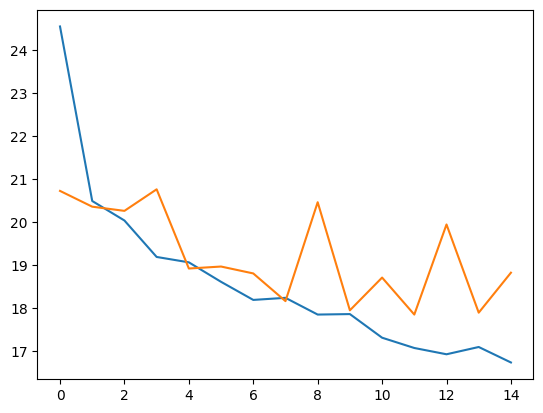

In [28]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [30]:
np.mean(y)

np.float64(63.14739106688866)

In [31]:
100 - 16 * 100 / 63

74.60317460317461

In [48]:
test_image = mpimg.imread('images (4).jpg')

In [49]:
test_image.shape

(183, 275, 3)

In [50]:
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)
test_image = cv2.resize(test_image, (150, 150))
test_image = test_image / 255
test_image = test_image.reshape(1, 150, 150, 1)


In [51]:
test_image

array([[[[0.3372549 ],
         [0.32941176],
         [0.31764706],
         ...,
         [0.29411765],
         [0.29803922],
         [0.30196078]],

        [[0.30980392],
         [0.30588235],
         [0.29803922],
         ...,
         [0.29019608],
         [0.29411765],
         [0.30196078]],

        [[0.30980392],
         [0.29803922],
         [0.29411765],
         ...,
         [0.28627451],
         [0.29019608],
         [0.29411765]],

        ...,

        [[0.58823529],
         [0.58823529],
         [0.58431373],
         ...,
         [0.73333333],
         [0.7372549 ],
         [0.7372549 ]],

        [[0.54901961],
         [0.54509804],
         [0.54117647],
         ...,
         [0.7254902 ],
         [0.73333333],
         [0.7372549 ]],

        [[0.51372549],
         [0.50980392],
         [0.50980392],
         ...,
         [0.72156863],
         [0.73333333],
         [0.7372549 ]]]], shape=(1, 150, 150, 1))

In [52]:
model.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[ 38.20574 ,  25.514223, 105.334076,  99.857605]], dtype=float32)

In [53]:
test_cordinates = model.predict(test_image).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [54]:
test_image = test_image.reshape(150, 150, 1)


In [56]:
test_image = test_image.copy()
test_image = cv2.rectangle(test_image, (38, 25), (105, 99), (0, 255, 255))

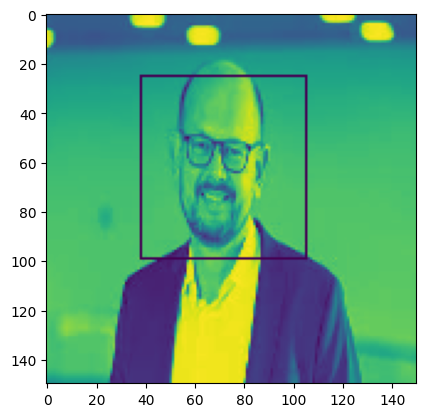

In [57]:
plt.imshow(test_image)

In [58]:
import pickle

In [59]:
with open('face_model.pkl', 'wb') as file:
    pickle.dump(model, file)